### Loading the dependencies

In [1]:
import random

#import simpy
import matplotlib.pyplot as plt
from itertools import accumulate
import pandas as pd  # version 2.0.3
import datetime
import numpy as np  ##  version 1.24.3
import pickle
import os
import sys
from matplotlib.figure import Figure
import math
import string
#from itertools import product
import time

### Obtaining resources and/or variables related data

In [2]:
work_direc =  r"\\esneft.nhs.uk\share\Finance\Capacity & Analytics\Business Informatics\Analytics Team\Surgical Elective Patient Scheduling Model\Optimal_Scheduling_Model\IO_data"
#os.chdir(work_direc)
#trained_models_direc = r"Z:\Capacity & Analytics\Business Informatics\Analytics Team\Surgical Elective Patient Scheduling Model\Theatre_Procedure_Time_Predictive_Modelling\Latest_Data_and_model"
trained_models_direc = r"\\esneft.nhs.uk\share\Finance\Capacity & Analytics\Business Informatics\Analytics Team\Surgical Elective Patient Scheduling Model\Theatre_Procedure_Time_Predictive_Modelling\Latest_data_and_model"
#os.chdir(trained_models_direc)

#### Sessions booking and patients related data

In [3]:
from procedure_time_and_variabiltiy_related_functions import load_timeslot_file
sessions_plan = load_timeslot_file( os.path.join(work_direc,'Feb_2026\Sample_Sessions_15.xlsx'))
sessions_plan = sessions_plan[sessions_plan['Consultant Code'].apply(lambda x : False if type(x) == 'int' or not str(x).startswith('C') or str(x).startswith('C9999') else True)]
#sessions_plan = sessions_plan.iloc[0:17,:]
#sessions_plan['Consultant Code'].value_counts()


In [4]:
#sessions_plan['Session ID']

In [5]:
#patient_df = pd.read_excel('Jan_Feb_2025/patient_list_jan_feb_250.xlsx')
patient_df = pd.read_excel(os.path.join(work_direc,'Feb_2026\\Sample_Cases_150.xlsx'))
#patient_data = pd.read_excel(os.path.join(work_direc,'July_Aug_2025\Patient_data.xlsx'))
#patient_data = pd.read_excel('Jan_Feb_2025/ESEOC_surgical_prepared_data_jan20_feb07.xlsx')

In [6]:
#pd.Series(patient_df["Procedure Priority"].values, index=patient_df["Patient ID"]).to_dict()

#### Surgical Time Prediction related Parameters including related data, and algorithms requirements

In [7]:
from procedure_time_and_variabiltiy_related_functions import get_prediction_required_parameters

In [8]:
procedure_time_prediction_parameters = get_prediction_required_parameters(work_direc, trained_models_direc)

In [9]:
#procedure_time_prediction_parameters


In [10]:
#procedure_time_prediction_parameters = (models_types, data_model_categorisation, pred_model_related_preprocessed_data, removed_data_from_processing,
#                                                              model_input_features_all, possible_varying_data_for_patient, force_encoding_cols, trained_models_direc)

### Scheduling Model- Initiating and data loading

In [11]:
from Scheduling_Model import Scheduling_Model

#### Initilising the scheduling_model

In [12]:
sched_model = Scheduling_Model(patient_df, sessions_plan)

In [13]:
#patient_df[patient_df['Intended Procedure Code'].isna()]

In [14]:
from procedure_time_and_variabiltiy_related_functions import compute_TASKS_average_surgical_time

In [15]:
#procedure_time_prediction_parameters[2][procedure_time_prediction_parameters[4]]


#### Generate Task Durations

In [16]:
sched_model.patients_df = patient_df.copy().set_index('Patient ID', drop=False)

sched_model.generate_tasks_durations(patient_df, sessions_plan, patient_df, procedure_time_prediction_parameters)
#input_data_df = compute_TASKS_average_surgical_time(sched_model.patients_df.copy(), sessions_plan, *procedure_time_prediction_parameters)

In [17]:
patient_df[patient_df['Patient ID'].isin(sched_model.TASKS_DURATION[sched_model.TASKS_DURATION.isna().all(axis=1)].index)]

,Patient ID,Gender,Age group at admit,Intended Procedure Code,Intended Procedure Description,EPIC Procedure Key,N_procedures,Specialty,Consultant Code,Consultant Name,Patient Classification,Procedure Priority,Planned Duration (min),RTT_ClockStart,RTT_WaitingWeeks
31,22064184,Male,31to50,W836,Arthroscopy of hip,49380,1,Orthopaedics,C7012778,"MASSA, EDWARD",Day case admission,P3,14,2025-05-08,40.0
32,20307348,Female,16to30,W836,Arthroscopy of hip,49380,1,Orthopaedics,C7012778,"MASSA, EDWARD",Day case admission,P3,140,2025-01-22,36.0
34,21471366,Female,31to50,W836,Arthroscopy of hip,49380,1,Orthopaedics,C7012778,"MASSA, EDWARD",Ordinary admission,P3,140,2025-05-02,41.0
35,22024042,Female,31to50,W836,Arthroscopy of hip,49380,1,Orthopaedics,C7012778,"MASSA, EDWARD",Day case admission,P3,14,NaT,NaN
51,21015955,Female,Above80,W954,Revision of total prosthetic replacement of hi...,12652,1,*Unspecified,C7012778,"MASSA, EDWARD",Ordinary admission,P3,14,2024-07-19,64.0
53,21108240,Female,31to50,W836,Arthroscopy of hip,49380,1,Orthopaedics,C7012778,"MASSA, EDWARD",Day case admission,P3,140,NaT,NaN
75,21498045,Male,31to50,W798,Exploration of joint,32825,1,Orthopaedics,C3326404,"MORGAN JONES, RHIDIAN",Ordinary admission,P4,14,2025-08-01,28.0
110,21981124,Female,71to80,X509,Unicompartmental replacement of knee,50320,1,Orthopaedics,C6074474,"PARRATT, TIMOTHY",Ordinary admission,P4,184,2025-05-22,38.0
140,20154453,Female,61to70,X509,Unicompartmental replacement of knee,50320,1,Orthopaedics,C4027799,"MARTIN, CHRISTOPHER",Ordinary admission,P4,184,2025-08-12,27.0


In [18]:
#sched_model.TASKS_DURATION

In [19]:
#sched_model.TASKS_DURATION[sched_model.TASKS_DURATION.isna().all(axis=1)].index
#patient_df[patient_df['Patient ID'] == id]['Planned Duration'].values[0]
#sched_model.TASKS_DURATION
#ids_no_duration

In [20]:
#proce_related_col = [col for col in patient_df.columns if 'procedure' in col.lower()][0]

#all_features_with_identifying_name = [proce_related_col if x == 'Actual Procedure 1 Code 1' else x for x in procedure_time_prediction_parameters[4] ]

#fixed_data_for_patient = [col for col in all_features_with_identifying_name if col not in procedure_time_prediction_parameters[5]]

#### Incorporate RTT Waiting Time (3rd Objective related data)

In [21]:
#wait_weeks_col = [col for col in patient_df.columns if 'wait' in col.lower() and 'week' in col.lower()][0]
#if wait_weeks_col in df_cases.columns:
#self.CASES_RTT_WAIT_WEEKS = pd.Series(df_cases[wait_weeks_col].values, index=df_cases["Patient ID"]).to_dict()
sched_model.add_cases_RTT_waiting_time(patient_df)
#sched_model.SUM_ALL_WAITING_WEEKS = sum(value for key, value in sched_model.CASES_RTT_WAIT_WEEKS.items())

In [22]:
#sched_model.SUM_ALL_SESSIONS_DURATION

#### Incorporate Surgery Priority (4th Objective related data)

In [23]:
sched_model.add_cases_surgery_Priority(patient_df)
sched_model.SUM_CASES_SURGERY_PRIORITISATION_REWARD

47.0

In [24]:
#sched_model.CASES_RTT_PRIORITY
#sched_model.CASES_RTT_WAIT_WEEKS

#### Generate and Store Task Duration Deviation Probabilities (2nd Objective requirement)

In [25]:
#2nd objective requirement
sched_model.generate_chances_for_tasks_durations(patient_df, sessions_plan ,30,None, procedure_time_prediction_parameters)
sched_model.obtain_mean_sd_for_tasks_durations_chances(patient_df, sessions_plan, 30, None, procedure_time_prediction_parameters)
#sched_model.update_sessions_df()

W836 not in past dataset
W836 not in past dataset
W836 not in past dataset
W836 not in past dataset
W954 not in past dataset
W836 not in past dataset
W798 not in past dataset
X509 not in past dataset
X509 not in past dataset
selected indices in total were 1179
ratio greater than 1 in total were 541


In [26]:
#sched_model.TASKS_DURATION_DEVIATION_RATIO_CHANCES_MEAN_SD

#### Set the theatre prep min required in between procedure and maximum session booking anticipated

In [27]:
sched_model.session_max_util = 0.9 # (default 0.9)
sched_model.theatre_prpn_min =  7.5 # (default 7.5)

In [27]:
sched_model.add_consultant_procedures_template(pd.read_excel(os.path.join(work_direc,'Consultant_procedure_template.xlsx')))

In [31]:
#sched_model.consultant_procedure_historical_count
#(_ for _ in  if _ in objectives)
#obj_weightage.values()
#sched_model.consultant_procedures_template_dict

### Solving with MIP solver (SCIP)

In [28]:
hyper_param_SCIP = {'time limit': len(patient_df)*len(sessions_plan)/20}

obj_weightage =  {'objective1':0.4, 'objective2':0.15, 'objective3':0.2*len(patient_df)/len(sessions_plan)/5,  'objective4':0.25*len(patient_df)/len(sessions_plan)/5}
objectives = ('objective1', 'objective2', 'objective3','objective4')
#objectives = ('objective1',)
sum_value = sum(_ for key, _ in obj_weightage.items() if key in objectives)
obj_weightage = {key: value/sum_value for key, value in obj_weightage.items()}
#
#optimisation_algorithm = 'MIP Solver'
#'objective1', 'objective3','objective4')
sched_model.create_schedule_with_optimisation(optimisation_algorithm = 'MIP Solver', objectives = objectives, 
                                  weightage= obj_weightage,
                                  hyper_param= hyper_param_SCIP,
                                  consult_patient_restriction= True,
                                   consult_procedure_restriction= True
                                             )

Node 1, Objective Value 0.645, Time Elapsed 0.0
Node 2, Objective Value 0.645, Time Elapsed 0.0
Node 4, Objective Value 0.645, Time Elapsed 0.0
Node 7, Objective Value 0.645, Time Elapsed 0.0
Node 9, Objective Value 0.645, Time Elapsed 0.0
Node 11, Objective Value 0.645, Time Elapsed 0.0
Node 13, Objective Value 0.645, Time Elapsed 0.0
Node 12, Objective Value 0.645, Time Elapsed 0.0
Node 17, Objective Value 0.645, Time Elapsed 0.0
Node 18, Objective Value 0.645, Time Elapsed 0.0
Node 21, Objective Value 0.645, Time Elapsed 0.0
Node 22, Objective Value 0.645, Time Elapsed 0.0
Node 8, Objective Value 0.645, Time Elapsed 0.0
Node 27, Objective Value 0.645, Time Elapsed 0.0
Node 29, Objective Value 0.645, Time Elapsed 0.0
Node 31, Objective Value 0.645, Time Elapsed 0.0
Node 32, Objective Value 0.645, Time Elapsed 0.0
Node 34, Objective Value 0.645, Time Elapsed 0.0
Node 16, Objective Value 0.645, Time Elapsed 0.0
Node 39, Objective Value 0.645, Time Elapsed 0.0
Node 41, Objective Value 0

In [29]:
sched_model.cases_not_considered

[20154453,
 21981124,
 21498045,
 21108240,
 21015955,
 22024042,
 21471366,
 20307348,
 22064184]

#### Model Result Testing

In [30]:
from optimisation_related_functions import multi_objectives
from data_processing_nd_encoding_related_functions import read_z_table

multi_objectives(sched_model, None, 0, cases_to_skip = sched_model.cases_not_considered, objectives_list = ('objective1', 'objective2', 'objective3', 'objective4'), prep_min= sched_model.theatre_prpn_min, cdf_table_data = read_z_table())

(0.8234953703703703, 0.81033125, 0.6994323274574246, 0.48404255319148937)

In [31]:
#df2 = pd.merge(sched_model.schedule_new, patient_df[['Patient ID', 'Consultant Code']], on = ['Patient ID'], how = 'left')
#df2[~pd.isna(df2['Consultant Code_y'])]
sched_model.sessions_updated

,Session ID,Session Planned Start Date/Time,Consultant Code,Theatre Name,Total Slot Minutes,Total Booked Minutes,Session Utilisation,Session Overrunning Chances
0,20260309|SVC-250|1228|815|0,2026-03-09 08:15:00,C4726342,COL ESEOC THEATRE 25,555.0,495.0,0.892,0.363
1,20260310|SVC-250|1228|815|0,2026-03-10 08:15:00,C7012778,COL ESEOC THEATRE 25,555.0,390.0,0.703,0.014
2,20260312|SVC-250|2585|815|0,2026-03-12 08:15:00,C3326404,COL ESEOC THEATRE 23,555.0,450.0,0.811,0.138
3,20260316|SVC-250|1228|815|0,2026-03-16 08:15:00,C4726342,COL ESEOC THEATRE 25,555.0,495.0,0.892,0.312
4,20260316|SVC-250|2585|815|0,2026-03-16 08:15:00,C2983125,COL ESEOC THEATRE 23,555.0,485.0,0.874,0.390
5,20260319|SVC-250|3814|815|0,2026-03-19 08:15:00,C4027799,COL ESEOC THEATRE 22,315.0,280.0,0.889,0.271
6,20260323|SVC-250|1228|815|0,2026-03-23 08:15:00,C4726342,COL ESEOC THEATRE 25,555.0,495.0,0.892,0.312
7,20260323|SVC-250|2585|815|0,2026-03-23 08:15:00,C2983125,COL ESEOC THEATRE 23,555.0,485.0,0.874,0.334
8,20260324|SVC-250|1228|815|0,2026-03-24 08:15:00,C7012778,COL ESEOC THEATRE 25,555.0,400.0,0.721,0.027
9,20260324|SVC-250|3814|815|0,2026-03-24 08:15:00,C6074474,COL ESEOC THEATRE 22,555.0,425.0,0.766,0.064


In [32]:
#ids_to_check = [id for id in patient_df[pd.isna(patient_df['Consultant Code'])]['Patient ID'].values if id in sched_model.schedule_new['Patient ID'].values]
#patient_df.head(15)
#pd.merge(sched_model.patients_not_scheduled[['Patient ID', 'Consultant Code', 'Intended Procedure Code']].reset_index(drop=True), patient_df[['Patient ID', 'Planned Duration']], on = 'Patient ID')

In [33]:
#sched_model.schedule_new.apply(lambda row: row['Intended Procedure Code'] in sched_model.consultant_procedures_template_dict[row['Consultant Code']], axis=1).unique()
#sched_model.sessions_updated
[sched_model.schedule_new.shape[0], sched_model.patients_not_scheduled.shape[0]]

[67, 87]

In [34]:
#sched_model.patients_not_scheduled[sched_model.patients_not_scheduled['Consultant Code'] == 'C6077137']

In [35]:
#sessions_plan
#sched_model.schedule_new[sched_model.schedule_new['Consultant Code'] == 'C6077137']
#patient_df[patient_df['Consultant Code'] == 'C6077137']

In [36]:
sched_model.schedule_new['Procedure Priority'] = sched_model.schedule_new['Patient ID'].map(sched_model.patients_df['Procedure Priority'])
sched_model.schedule_new['Procedure Priority Reward'] = sched_model.schedule_new['Patient ID'].map(sched_model.CASES_SURGERY_PRIORITISATION_REWARD)
sched_model.schedule_new['RTT WAIT WEEKS'] = sched_model.schedule_new['Patient ID'].map(sched_model.CASES_RTT_WAIT_WEEKS)
#sched_model.schedule_new
sched_model.patients_not_scheduled['Procedure Priority'] = sched_model.patients_not_scheduled['Patient ID'].map(sched_model.patients_df['Procedure Priority'])
sched_model.patients_not_scheduled['Procedure Priority Reward'] = sched_model.patients_not_scheduled['Patient ID'].map(sched_model.CASES_SURGERY_PRIORITISATION_REWARD)
#sched_model.patients_not_scheduled
sched_model.patients_not_scheduled['RTT WAIT WEEKS'] = sched_model.patients_not_scheduled['Patient ID'].map(sched_model.CASES_RTT_WAIT_WEEKS)
#

In [37]:
#pd.merge(sched_model.schedule_new, sched_model.patients_df[['Patient ID', 'Procedure Priority']].reset_index(), how = 'left', on = ['Patient ID'])


In [38]:
sched_model.patients_df['Procedure Priority'].value_counts()

Procedure Priority
P4    116
P3     27
P2      6
Name: count, dtype: int64

In [39]:
sched_model.schedule_new['Procedure Priority'].value_counts()

Procedure Priority
P4    45
P3    14
P2     6
Name: count, dtype: int64

In [35]:
sched_model.patients_not_scheduled['Procedure Priority Reward'].value_counts()

Procedure Priority Reward
0.25    29
0.50    14
0.75     3
Name: count, dtype: int64

In [34]:
#sched_model.schedule_new
[sched_model.schedule_new['RTT WAIT WEEKS'].mean(), sched_model.patients_not_scheduled['RTT WAIT WEEKS'].mean()]

[50.6463700234192, 49.298136645962735]

In [12]:
#[(key, value) for key, value in sched_model.CASES_SURGERY_PRIORITISATION_REWARD.items() if key in sched_model.schedule_new['Patient ID'].values]

### Schedule Visualisation

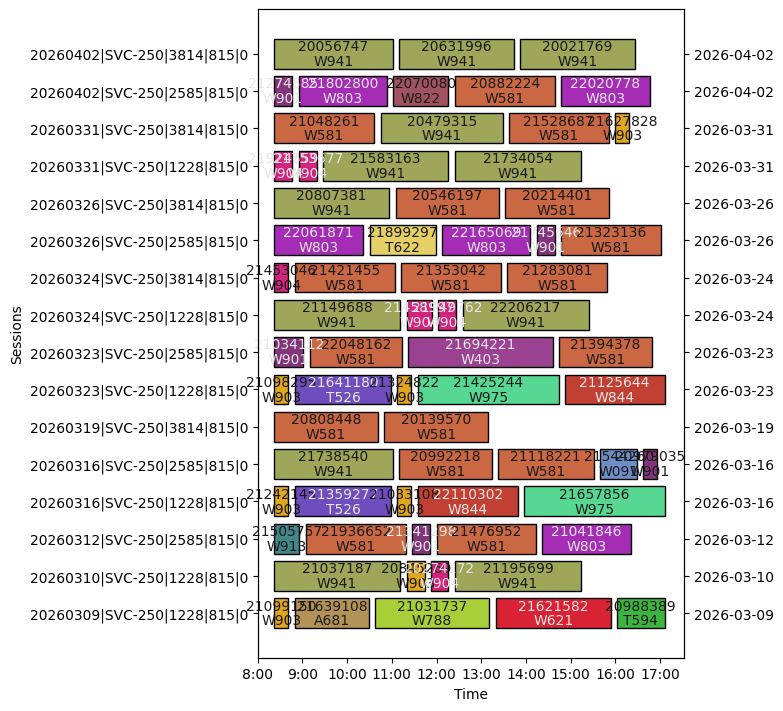

In [41]:
from procedure_time_and_variabiltiy_related_functions import plot_theatre_occupancy_data
with open(os.path.join(work_direc,'label_mapping.pickle'), 'rb') as file:
    label_mapping = pickle.load(file)

ax2= plot_theatre_occupancy_data(sched_model.schedule_new[['Scheduled Start Date/Time', 'Planned H4 Minutes', 'Patient ID', 'Intended Procedure Code', 'Session ID', 'Consultant Code']], (5.5,len(sessions_plan)/1.9), label_mapping, color_mapping_col= 'Intended Procedure Code' , grouping_col='Session ID' )

In [44]:
#ax2.get_figure().savefig(os.path.join(work_direc,'Output_files\schedule_output.png'),dpi=300, bbox_inches='tight')

In [ ]:
#[(key, val1) for key,val1 in sched_model.TASKS_DURATION_DEVIATION_RATIO_CHANCES_MEAN_SD.items() if not isinstance(val1, list) and key[0] not in sched_model.cases_not_considered]

[]

### Solving with Simulated Annealing Algorithm

In [46]:
# Simulated Annealing parameters
hyper_para_sim = {'INITIAL_TEMPERATURE': 100000 , 'FINAL_TEMPERATURE' : 0.00001, 
                  'ALPHA' : 0.999, 'MAX_ITERATIONS' : 100000}

#obj_weightage = {'objective1':0.75, 'objective2':0.25}
obj_weightage = {'objective1':0.75, 'objective2':0.25}
#obj_weightage = {'objective1':1}


#sol_weightage = (0.8, 0.2)
sol_weightage = (0.4, 0.3, 0.4)

start_time = time.time()

sched_model.create_schedule_with_optimisation(optimisation_algorithm = 'Simulated Annealing', 
                                              objectives = ('objective1', 'objective2', 'objective3', 'objective4'), 
                                              weightage= obj_weightage,
                                              best_solution_weightage= sol_weightage,
                                              hyper_param= hyper_para_sim, 
                                             sessions_selection_prioritise= True,
                                             consult_patient_restriction= True)
end_time = time.time()
total_time = end_time - start_time
print("Total time:", total_time, "seconds")

Running Optimisation Problem with Simulated Annealing Algorithm
100th iterations is completed with current solution value reached [0.3884, 0.0511, 0.0904]
200th iterations is completed with current solution value reached [0.4794, 0.092, 0.1436]
300th iterations is completed with current solution value reached [0.5284, 0.1273, 0.1755]
400th iterations is completed with current solution value reached [0.5757, 0.1578, 0.2021]
500th iterations is completed with current solution value reached [0.6158, 0.1966, 0.234]
600th iterations is completed with current solution value reached [0.6403, 0.1996, 0.2394]
700th iterations is completed with current solution value reached [0.7018, 0.2689, 0.3032]
800th iterations is completed with current solution value reached [0.72, 0.2832, 0.3138]
900th iterations is completed with current solution value reached [0.731, 0.2832, 0.3245]
1000th iterations is completed with current solution value reached [0.731, 0.2832, 0.3245]
1100th iterations is completed 

In [47]:
#max([pop['f'][0] for pop in sched_model.pareto_archive])
#sched_model.SUM_CASES_SURGERY_PRIORITISATION_REWARD
#sched_model.SUM_CASES_SURGERY_PRIORITISATION_REWARD
multi_objectives(sched_model, None, 0, cases_to_skip = sched_model.cases_not_considered, objectives_list = ('objective1', 'objective2', 'objective3', 'objective4'), prep_min= sched_model.theatre_prpn_min, cdf_table_data = read_z_table())

(0.8356481481481481, 0.7789125, 0.507021213026591, 0.5)

In [32]:
#sched_model.best_solution
sched_model.cases_not_considered

In [33]:
#multi_objectives(sched_model, None, 0, cases_to_skip = sched_model.cases_not_considered, objectives_list = ('objective1', 'objective3', 'objective4'), prep_min= sched_model.theatre_prpn_min, cdf_table_data = read_z_table(), individual=sched_model.best_solution.T.flatten())

#### Model Result Testing

In [32]:
from optimisation_related_functions import multi_objectives

from data_processing_nd_encoding_related_functions import read_z_table

multi_objectives(sched_model, None, 0, cases_to_skip = sched_model.cases_not_considered, objectives_list = ('objective1', 'objective2', 'objective3'), prep_min= sched_model.theatre_prpn_min, cdf_table_data = read_z_table(), individual=sched_model.best_solution.T.flatten())

(0.8273273273273274, 0.8433736842105263, 0.6590277777777778)

In [34]:
sched_model.patients_df['Procedure Priority'].value_counts()

Procedure Priority
P4    46
P3    24
Name: count, dtype: int64

In [39]:
sched_model.schedule_new['Procedure Priority'] = sched_model.schedule_new['Patient ID'].map(sched_model.patients_df['Procedure Priority'])
sched_model.schedule_new['Procedure Priority Reward'] = sched_model.schedule_new['Patient ID'].map(sched_model.CASES_SURGERY_PRIORITISATION_REWARD)

sched_model.schedule_new['Procedure Priority Reward'].value_counts()

Procedure Priority Reward
0.25    31
0.00    25
0.50    15
Name: count, dtype: int64

In [37]:
sched_model.patients_not_scheduled['Procedure Priority'] = sched_model.patients_not_scheduled['Patient ID'].map(sched_model.patients_df['Procedure Priority'])
sched_model.patients_not_scheduled['Procedure Priority Reward'] = sched_model.patients_not_scheduled['Patient ID'].map(sched_model.CASES_SURGERY_PRIORITISATION_REWARD)
#sched_model.patients_not_scheduled

In [40]:
#sched_model.schedule_new['Procedure Priority Reward'].value_counts()

In [41]:
#patient_df['Procedure Priority'].value_counts()
sched_model.patients_not_scheduled['Procedure Priority Reward'].value_counts()

Procedure Priority Reward
0.25    15
0.00    12
0.50     9
Name: count, dtype: int64

#### Schedule Visualisation

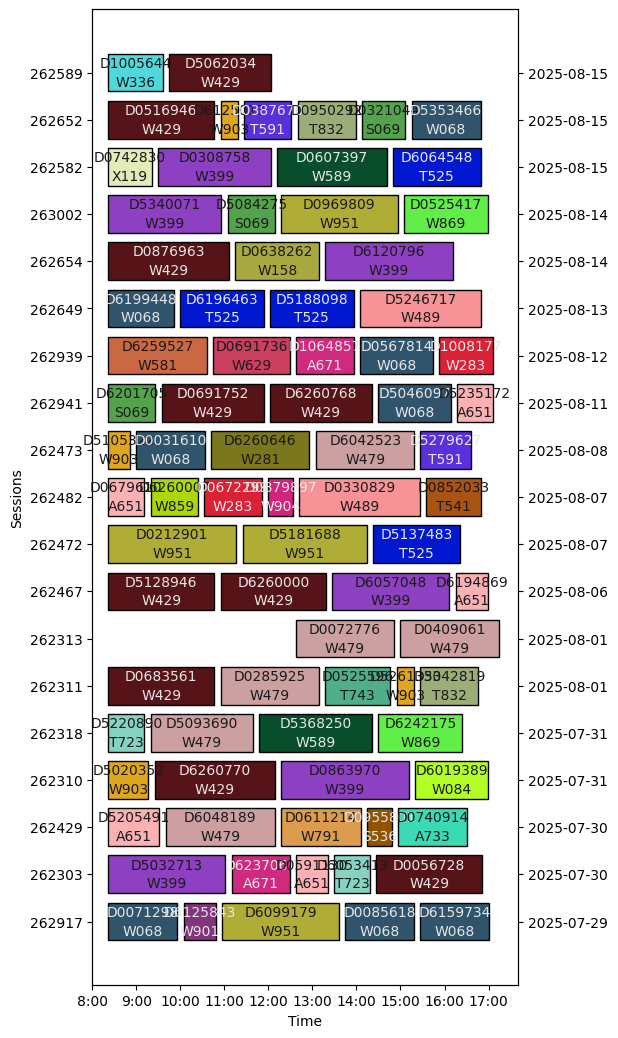

In [159]:
from procedure_time_and_variabiltiy_related_functions import plot_theatre_occupancy_data
with open(os.path.join(work_direc,'label_mapping.pickle'), 'rb') as file:
    label_mapping = pickle.load(file)

ax2= plot_theatre_occupancy_data(sched_model.schedule_new[['Scheduled Start Date/Time', 'Planned H4 Minutes', 'Patient ID', 'Intended Procedure Code', 'Session ID']], (5.5,len(sessions_plan)/1.5), label_mapping, color_mapping_col= 'Intended Procedure Code' , grouping_col='Session ID' )

In [160]:
sched_model.sessions_updated

,Session ID,Session Planned Start Date/Time,Consultant Code,Theatre Name,Total Slot Minutes,Total Booked Minutes,Session Utilisation
0,262917,2025-07-29 08:15:00,C7590715,Theatre 23,555.0,490.0,0.883
1,262303,2025-07-30 08:15:00,C4537935,Theatre 22,555.0,480.0,0.865
2,262429,2025-07-30 08:15:00,C4521035,Theatre 18,555.0,460.0,0.829
3,262310,2025-07-31 08:15:00,C4521035,Theatre 24,555.0,495.0,0.892
4,262318,2025-07-31 08:15:00,C6163962,Theatre 25,555.0,460.0,0.829
5,262311,2025-08-01 08:15:00,C6077137,Theatre 24,555.0,475.0,0.856
6,262313,2025-08-01 12:30:00,C7590715,Theatre 20,300.0,270.0,0.900
7,262467,2025-08-06 08:15:00,C4537935,Theatre 22,555.0,495.0,0.892
8,262482,2025-08-07 08:15:00,C6163962,Theatre 25,555.0,470.0,0.847
9,262472,2025-08-07 08:15:00,C4521035,Theatre 24,555.0,465.0,0.838


### Functions and Model

In [53]:
#sched_model.sessions_df['Consultant Code']

In [45]:
from optimisation_related_functions import create_optimum_schedule

create_optimum_schedule(sched_model.patients_df,
        sched_model.sessions_df, 
        sched_model.TASKS_DURATION,
        sched_model, 
        'Simulated Annealing', 
        objectives = ('objective1', 'objective2', 'objective3', 'objective4'),                                                                
        weightage =  {'objective1':0.75, 'objective2':0.25}, 
        best_solution_weightage = (0.4, 0.3, 0.4),
        hyper_param = {'INITIAL_TEMPERATURE': 100000 , 'FINAL_TEMPERATURE' : 0.00001, 
                  'ALPHA' : 0.999, 'MAX_ITERATIONS' : 100000}, 
        solutions_only = True, 
        sessions_selection_prioritise = False,
        #consult_procedure_restriction = consult_procedure_restriction,
        consult_patient_restriction = True
                       )

Running Optimisation Problem with Simulated Annealing Algorithm
100th iterations is completed with current solution value reached [0.3871, 0.0535, 0.0851]
200th iterations is completed with current solution value reached [0.4422, 0.1094, 0.1117]
300th iterations is completed with current solution value reached [0.5419, 0.193, 0.1755]
400th iterations is completed with current solution value reached [0.6338, 0.2298, 0.2287]
500th iterations is completed with current solution value reached [0.6499, 0.2555, 0.2447]
600th iterations is completed with current solution value reached [0.6498, 0.2605, 0.2447]
700th iterations is completed with current solution value reached [0.6736, 0.3033, 0.2766]
800th iterations is completed with current solution value reached [0.699, 0.3418, 0.3191]
900th iterations is completed with current solution value reached [0.7045, 0.3627, 0.3191]
1000th iterations is completed with current solution value reached [0.7042, 0.3705, 0.3351]
1100th iterations is comple

(None,
 None,
 [22064184,
  20307348,
  21471366,
  22024042,
  21015955,
  21108240,
  21498045,
  21981124,
  20154453],
 None,
 [{'x': array([[0, 1, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 1, 0, 0]]),
   'f': [0.8184, 0.4733, 0.4681]},
  {'x': array([[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 1, 0, 0]]),
   'f': [0.8226, 0.473, 0.4574]},
  {'x': array([[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 1, 0, 0]]),
   'f': [0.8226, 0.473, 0.4574]},
  {'x': array([[0, 0, 1, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 

In [ ]:
# Simulated Annealing parameters
hyper_para_sim = {'INITIAL_TEMPERATURE': 100000 , 'FINAL_TEMPERATURE' : 0.00001, 
                  'ALPHA' : 0.999, 'MAX_ITERATIONS' : 100000}

#obj_weightage = {'objective1':0.75, 'objective2':0.25}
#obj_weightage = {'objective1':0.75, 'objective2':0.25}
obj_weightage = {'objective1':1}


#sol_weightage = (0.8, 0.2)
sol_weightage = (0.4, 0.3, 0.4)

start_time = time.time()

sched_model.create_schedule_with_optimisation(optimisation_algorithm = 'Simulated Annealing', 
                                              objectives = ('objective1', 'objective3', 'objective4'), 
                                              #weightage= obj_weightage,
                                              best_solution_weightage= sol_weightage,
                                              hyper_param= hyper_para_sim, 
                                             #sessions_selection_prioritise= False,
                                             consult_patient_restriction= True)
end_time = time.time()
total_time = end_time - start_time
print("Total time:", total_time, "seconds")

In [28]:
#sched_model.consultant_procedure_historical_count.loc['W953', 'C3320752']

#### Procedure time prediction related

In [ ]:
from procedure_time_and_variabiltiy_related_functions import create_model_name, prepare_input_data
target_data_type = 'H4 Minutes'
feature_variables_names = procedure_time_prediction_parameters[4]
model_sub_level = procedure_time_prediction_parameters[1]
model_type = 'BayesianRidge'
model_name = create_model_name(model_type, target_data_type, feature_variables_names, model_sub_level)

    
model_folder = procedure_time_prediction_parameters[-1]

if os.path.exists(os.path.join(model_folder, model_name +'.pkl')):
    with open(os.path.join(model_folder, model_name +'.pkl'), 'rb') as file:
        model_train_results = pickle.load(file)
        
else:
    raise ValueError(f"The corresponding trained model {model_name} is not available for prediction in the folder: {model_folder}")
    

In [49]:
sol_arr = np.zeros((20,100))

In [81]:
best_sol = np.array([_ for _ in sched_model.TASKS_ASSIGNED.values()]).reshape(100,20).T

In [105]:

#best_sol[f"x({1},{2})"]
best_sol[0,0] = 1

In [100]:
#sched_model2 = Scheduling_Model(patient_df, sessions_plan)
sched_model2 = sched_model
sched_model2.consultant_procedures_template_dict = sched_model.consultant_procedures_template_dict

In [112]:
changed_sessions_indices = [0,3]
satisfies_constraints(sched_model2, 
       individual = best_sol.T.flatten(),
       cases_to_skip=[],
       specific_sessions = [sched_model2.SESSIONS[_] for _ in changed_sessions_indices],
       cases_repetition_test = False
        )

False

In [107]:
satisfies_soft_constraints(
                sched_model2,
                best_sol,
                [0,2],
                'Intended Procedure Code'
            )

False

In [109]:
from optimisation_related_functions import cases_total_duration_for_session, session_assignment_constraint
def satisfies_constraints(model, individual = None, cases_to_skip = [], specific_sessions = [], cases_repetition_test = True):
    # Implement constraint checking logic here
        #Evaluate SESSION_ASSIGNMENT constraint
    if len(specific_sessions) == 0:
        specific_sessions = model.SESSIONS
    if individual is not None:
        for task, value in zip(model.TASKS, individual):
            model.TASKS_ASSIGNED[task] = value

    if cases_repetition_test:
        for case in model.CASES:
            if case in cases_to_skip:
                continue
            constraint_check = session_assignment_constraint(model, case)
            if not constraint_check[0]:
                return False  
                
    for session in specific_sessions:
        constraint_check = cases_total_duration_for_session(model, session, cases_to_skip)
        if not constraint_check[0]:
            return False 
                
    return True

In [103]:
def satisfies_soft_constraints(model, solution_2d_arr, sessions_index_for_checking, proce_col):
    # Implement constraint checking logic here
        #Evaluate SESSION_ASSIGNMENT constraint
    for i in sessions_index_for_checking:
        consultant = model.sessions_df.iloc[i]['Consultant Code']
        for j, procedure in enumerate(model.patients_df[proce_col]):
            if solution_2d_arr[i,j] == 0:
                continue
            if not consultant in model.consultant_procedures_template_dict or not procedure in model.consultant_procedures_template_dict[consultant]:
                return False 
                
    return True

### Data filtering part

In [28]:
from data_processing_nd_encoding_related_functions import data_prep_first_step_after_SQl_extraction

In [31]:
proce_cols = ('Intended Procedure Code',	'Intended Secondary 1 Procedure Code',	'Intended Secondary 2 Procedure Code')

#data_prep_first_step_after_SQl_extraction(os.path.join(work_direc,'July_Aug_2025\Patient_data_SQL.xlsx'), os.path.join(work_direc,'July_Aug_2025\Patient_data.xlsx'), proce_cols)

In [32]:
from procedure_time_and_variabiltiy_related_functions import load_timeslot_file
sessions_plan = load_timeslot_file( os.path.join(work_direc,'July_Aug_2025\Future_TandO_Sessions.xlsx'))
sessions_plan = sessions_plan[sessions_plan['Consultant Code'].apply(lambda x : False if type(x) == 'int' or not str(x).startswith('C') or str(x).startswith('C9999') else True)]

#sessions_plan['Consultant Code'].value_counts()


In [33]:
#patient_df = pd.read_excel('Jan_Feb_2025/patient_list_jan_feb_250.xlsx')
patient_df = pd.read_excel(os.path.join(work_direc,'July_Aug_2025\Patient_data.xlsx'))
#patient_data = pd.read_csv(os.path.join(work_direc,'July_Aug_2025\Patient_data.csv'))
#patient_data = pd.read_excel('Jan_Feb_2025/ESEOC_surgical_prepared_data_jan20_feb07.xlsx')

In [34]:
sessions_plan['Consultant Session Count'] = sessions_plan.groupby('Consultant Code').cumcount()+1
sessions_plan['Consultant Session Total Count'] = sessions_plan['Consultant Code'].map(sessions_plan['Consultant Code'].value_counts())

In [64]:
#sessions_plan
sessions_plan_filtered = sessions_plan[sessions_plan['Consultant Session Total Count'] > 2].copy()
#sessions_plan_filtered = sessions_plan[(sessions_plan['Consultant Session Total Count'] > 2) & (sessions_plan['Consultant Session Count'] < sessions_plan['Consultant Session Total Count'])]

In [65]:
#

In [66]:
#sessions_plan
sessions_plan_filtered.loc[:,'Consultant All Sessions Time'] = sessions_plan_filtered['Consultant Code'].map(sessions_plan_filtered.groupby('Consultant Code')['Total Slot Minutes'].sum())

In [67]:
patient_df.loc[:,'Consultant All Surgery Time'] = patient_df['Consultant Code'].map(patient_df.groupby('Consultant Code')['Planned Duration'].sum())

In [68]:
patient_df_filtered = patient_df[patient_df['Consultant Code'].isin(sessions_plan_filtered['Consultant Code'].values)].copy()


In [69]:
patient_df_filtered['Consultant All Sessions Time'] = patient_df_filtered['Consultant Code'].map(sessions_plan_filtered.groupby('Consultant Code')['Total Slot Minutes'].sum())

In [70]:
patient_df_filtered = patient_df_filtered[patient_df_filtered['Consultant All Surgery Time'] > patient_df_filtered['Consultant All Sessions Time']]

In [71]:
sessions_plan_filtered = sessions_plan_filtered[sessions_plan_filtered['Consultant Code'].isin(patient_df_filtered['Consultant Code'].values)]

In [72]:
#patient_df_filtered.shape
sessions_plan_filtered.shape

(19, 24)

In [73]:
#sessions_plan_filtered['Consultant Code'].value_counts()

In [75]:
patient_df_filtered.to_excel(os.path.join(work_direc,'July_Aug_2025\Patient_list.xlsx'), index=False)

In [74]:
sessions_plan_filtered.to_excel( os.path.join(work_direc,'July_Aug_2025\Future_TandO_Sessions_filtered.xlsx'), index= False)

In [76]:
a = []

IndexError: list index out of range

In [ ]:
from procedure_time_and_variabiltiy_related_functions import combined_mean_sd
from pyscipopt import Model, Eventhdlr, SCIP_EVENTTYPE, quicksum    #Version: 5.1.1
from optimisation_related_functions import solve_optimisation_problem_with_MIP_solver

solve_optimisation_problem_with_MIP_solver(sched_model,
                    possible_task_durations_df = sched_model.TASKS_DURATION, 
                    objectives = objectives, 
                    obj_weightage = obj_weightage, 
                    hyper_param = hyper_param_SCIP,
                    consider_consult_procedure_combination = True,
                    consider_consult_patient_combination = True
                    )